# Machine Vision
## Assignment 6 - Triangulation



## Introduction

In this assignment, we will first project known 3D points onto a pair of stereo images using camera projection matrices. Then, we will triangulate 3D points from 2D correspondences. Let's first display the test images and the 2D point correspondences. We also load the 3D points. The data is from __http://www.robots.ox.ac.uk/~vgg/data/mview__.

(np.float64(-0.5), np.float64(1023.5), np.float64(767.5), np.float64(-0.5))

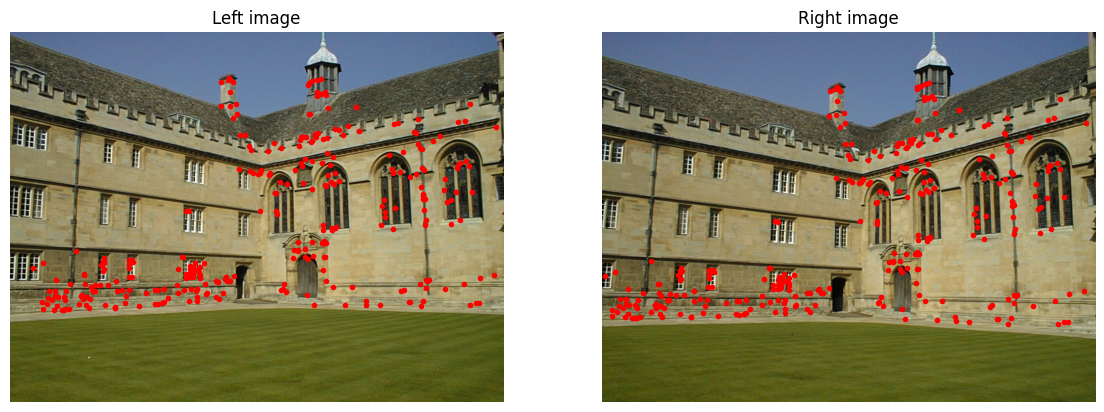

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline

# Load image pair and convert to RGB
left = cv2.imread('left.jpg')
right = cv2.imread('right.jpg')
left = cv2.cvtColor(left, cv2.COLOR_BGR2RGB)
right = cv2.cvtColor(right, cv2.COLOR_BGR2RGB)

# Load 2D points (2xN matrices)
pts1 = np.load('pts1.npy')
pts2 = np.load('pts2.npy')

# Load 3D points (3xN matrix)
pts3D = np.load('pts3D.npy')

# Display 2D point correspondences
plt.figure(figsize=(14,8))
plt.subplot(121)
plt.imshow(left)
plt.plot(pts1[0,:], pts1[1,:], '.r')
plt.title('Left image')
plt.axis('off')
plt.subplot(122)
plt.imshow(right)
plt.plot(pts2[0,:], pts2[1,:], '.r')
plt.title('Right image')
plt.axis('off')


The camera projection matrices $\mathbf{C}$ and $\mathbf{C}'$ are also provided for both views.

In [2]:
# Load 3x4 camera projection matrices
C1 = np.load('C1.npy')
C2 = np.load('C2.npy')

## Task 1 - Project 3D points <span style="color: red;">(0.5 points)</span>

Project the given 3D points onto the image plane using the camera projection matrix $\mathbf{C} = \mathbf{K}[\mathbf{R} | \mathbf{t}]$. This involves transforming the 3D Euclidean coordinates into 2D image coordinates using the equation:

$$
s \begin{pmatrix}u \\ v \\ 1 \end{pmatrix} = \mathbf{C} \begin{pmatrix} X \\ Y \\ Z \\ 1 \end{pmatrix} \qquad \qquad (1)
$$

where homogeneous coordinates are used. Complete the function `projectPts` by following the instructions below. The result should look like the previous figure.

### Instructions
1. Convert the 3D points `pts3D` from Euclidean to homogeneous coordinates.
2. Apply Equation 1 to project the points onto the image plane.
3. Convert the projected 2D homogeneous coordinates back to Euclidean coordinates.

(np.float64(-0.5), np.float64(1023.5), np.float64(767.5), np.float64(-0.5))

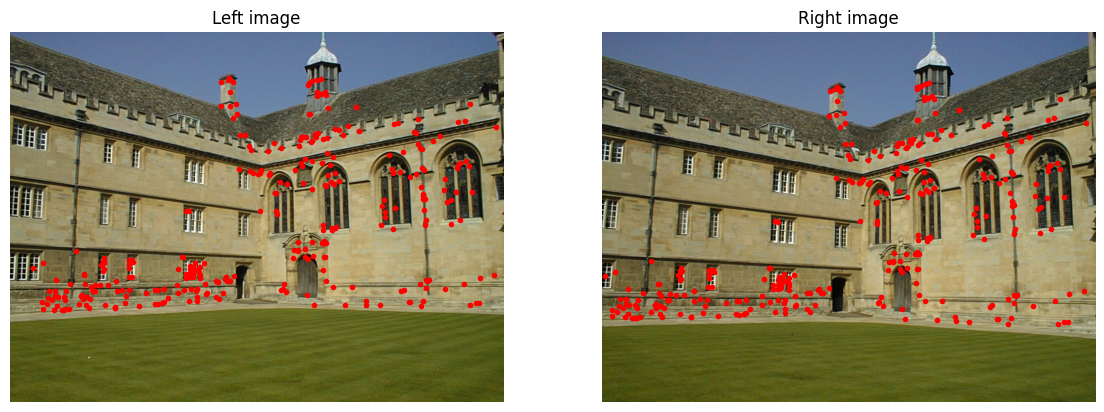

In [3]:
# INPUT
# pts3D : 3D points (X,Y,Z) (3xN matrix)
# C     : Camera projection matrix (3x4 matrix)
#
# OUTPUT
# pts2D : 2D points (x,y) (2xN matrix)
#
def projectPts(pts3D, C):

    N = pts3D.shape[1] # Number of points

    # ---------- YOUR CODE STARTS HERE -----------

    homogeneous = np.vstack((pts3D,np.ones((1,N))))
    Proj_homo = C @ homogeneous
    pts2D = Proj_homo[:2,:] / Proj_homo[2,:]

    # ----------- YOUR CODE ENDS HERE ------------

    assert pts2D.shape == (2, N), f"Expected pts2D shape (2, {N}), got {pts2D.shape}"

    return pts2D


# Project 3D points and visualize the result
points1 = projectPts(pts3D, C1)
points2 = projectPts(pts3D, C2)

plt.figure(figsize=(14,8))
plt.subplot(121)
plt.imshow(left)
plt.plot(points1[0,:], points1[1,:], '.r')
plt.title('Left image')
plt.axis('off')
plt.subplot(122)
plt.imshow(right)
plt.plot(points2[0,:], points2[1,:], '.r')
plt.title('Right image')
plt.axis('off')

In [ ]:
# LEAVE EMPTY

## Task 2 - Triangulation <span style="color: red;">(1.5 points)</span>

A linear method for triangulating a point observed in two cameras is described in **Exercise 4**.

Given a point $\mathbf{X} = (X,Y,Z)^{\top}$ the projection equations are:

$$
\begin{pmatrix}
s u \\
s v \\
s \end{pmatrix} =
\begin{pmatrix}
c_{11} & c_{12} & c_{13} & c_{14} \\
c_{21} & c_{22} & c_{23} & c_{24} \\
c_{31} & c_{32} & c_{33} & c_{34} \end{pmatrix}
\begin{pmatrix}
X \\
Y \\
Z \\
1 \end{pmatrix}
$$

$$
\begin{pmatrix}
t u' \\
t v' \\
t \end{pmatrix} =
\begin{pmatrix}
c_{11}' & c_{12}' & c_{13}' & c_{14}' \\
c_{21}' & c_{22}' & c_{23}' & c_{24}' \\
c_{31}' & c_{32}' & c_{33}' & c_{34}' \end{pmatrix}
\begin{pmatrix}
X \\
Y \\
Z \\
1 \end{pmatrix}
$$

Here we have used the same notation as in the exercise. Eliminating $s$ and $t$ we obtain the system of equations:

$$
(c_{31} u - c_{11}) X + (c_{32} u - c_{12}) Y + (c_{33} u - c_{13}) Z = c_{14} - c_{34} u
$$
$$
(c_{31} v - c_{21}) X + (c_{32} v - c_{22}) Y + (c_{33} v - c_{23}) Z = c_{24} - c_{34} v
$$
$$
(c_{31}' u' - c_{11}') X + (c_{32}' u' - c_{12}') Y + (c_{33}' u' - c_{13}') Z = c_{14}' - c_{34}' u'
$$
$$
(c_{31}' v' - c_{21}') X + (c_{32}' v' - c_{22}') Y + (c_{33}' v' - c_{23}') Z = c_{24}' - c_{34}' v'
$$

which can be expressed in a linear system of the form $\mathbf{Ax} = \mathbf{b}$ and solved using the least squares method.

### Instructions
- Implement the function `triangulatePts` to estimate 3D points given 2D points `pts1` and `pts2` and projection matrices `C1` and `C2`.
- For each point, form the linear system $\mathbf{Ax} = \mathbf{b}$, where $\mathbf{A}$ is a $4 \times 3$ matrix and $\mathbf{b}$ is a $4 \times 1$ vector.
- Solve for $\hat{\mathbf{x}}$ using the least-squares method $\hat{\mathbf{x}} = (\mathbf{A}^{\top} \mathbf{A})^{-1} \mathbf{A}^{\top} \mathbf{b}$, , where $\hat{\mathbf{x}}$ contains the coordinates of the 3D point $(X,Y,Z)$.
- Run the code cell to verify your implementation. The function is correct if the estimated 3D points `pts3D_tri` overlap with the given 3D points `pts3D`.

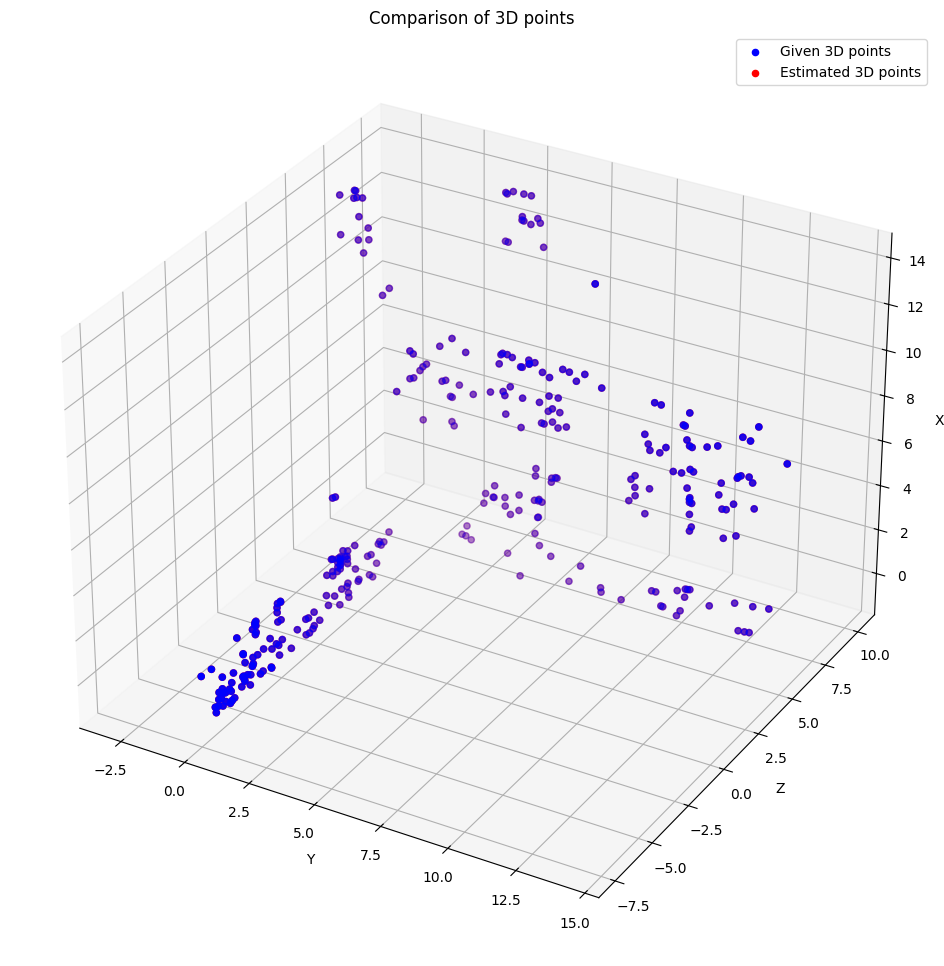

In [4]:
# INPUT
# pts1 : 2D points from the first image (2xN matrix)
# pts2 : 2D points from the second image (2xN matrix)
# C1   : Camera matrix for the first image (3x4 matrix)
# C2   : Camera matrix for the second image (3x4 matrix)
#
# OUTPUT
# pts3D_tri : Triangulated 3D points (X,Y,Z) (3xN matrix)
#
def triangulatePts(pts1, pts2, C1, C2):

    N = pts1.shape[1] # Number of points
    pts3D_tri = np.zeros((3,N), dtype=np.float32)

    # ---------- YOUR CODE STARTS HERE -----------
    for i in range(N):

      u1,v1 = pts1[:,i]
      u2,v2 = pts2[:,i]

      A=np.zeros((4,3))
      b=np.zeros((4,))

      A[0,:] =  u1 * C1[2,:3] - C1[0,:3]
      A[1,:] =  v1 * C1[2,:3] - C1[1,:3]
      A[2,:] =  u2 * C2[2,:3] - C2[0,:3]
      A[3,:] =  v2 * C2[2,:3] - C2[1,:3]

      b[0] =  C1[0,3] - u1 * C1[2,3]
      b[1] =  C1[1,3] - v1 * C1[2,3]
      b[2] =  C2[0,3] - u2 * C2[2,3]
      b[3] =  C2[1,3] - v2 * C2[2,3]

      X_3D=np.linalg.inv(A.T @ A) @ A.T @ b
      pts3D_tri[:,i] = X_3D




    # ----------- YOUR CODE ENDS HERE ------------

    assert pts3D_tri.shape == (3, N), f"Expected pts3D_tri shape (3, {N}), got {pts3D_tri.shape}"

    return pts3D_tri


# Triangulate points and compare to given 3D points
pts3D_tri = triangulatePts(pts1, pts2, C1, C2)

fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(-pts3D[1,:], pts3D[2,:], -pts3D[0,:],
           color='blue', label='Given 3D points')
ax.scatter(-pts3D_tri[1,:], pts3D_tri[2,:], -pts3D_tri[0,:],
           color='red', label='Estimated 3D points')
ax.set_xlabel('Y')
ax.set_ylabel('Z')
ax.set_zlabel('X')
ax.set_title('Comparison of 3D points')
ax.legend()


In [ ]:
# LEAVE EMPTY